# Batch assessment and Harmony integration

Merge the cleaned per-sample objects, inspect sample-associated structure before Harmony, run Harmony on PCA coordinates, then inspect the corrected embedding and save the post-Harmony checkpoint.


In [1]:
from pathlib import Path
import sys

import harmonypy as hm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [2]:
PROJECT_ROOT = Path("/nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics")
sys.path.append(str(PROJECT_ROOT / "src"))

from c9_snrnaseq.expression_preprocessing import normalize_counts, log_transform, select_hvgs, scale_expression
from c9_snrnaseq.dimensionality_reduction import run_pca, build_neighbor_graph, run_umap
from c9_snrnaseq.annotation import run_leiden_clustering, find_cluster_markers

sns.set_theme(style='whitegrid', context='talk')

In [3]:
FIGURES_DIR = PROJECT_ROOT / "results" / "08_batch_assessment_26donors" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "08_batch_assessment_26donors" / "tables"

MERGED_PATH = PROJECT_ROOT / "data" / "processed" / "merged" / "merged_after_clustering_26donors.h5ad"
HARMONY_PATH = PROJECT_ROOT / "data" / "processed" / "merged" / "adata_hm_after_harmony_26donors.h5ad"

SAMPLE_SHEET = PROJECT_ROOT / "data" / "metadata" / "samples.csv"
PER_SAMPLE_DIR = PROJECT_ROOT / "data" / "processed" / "per_sample"

for path in [FIGURES_DIR, TABLES_DIR, MERGED_PATH.parent]:
    path.mkdir(parents=True, exist_ok=True)

REBUILD_MERGED_OBJECT = False
FIGURE_DPI = 300
HARMONY_KEY = "X_pca_harmony"
HARMONY_CLUSTER_KEY = "leiden_harmony"
HARMONY_RESOLUTION = 0.6

## Small utilities


In [4]:
def save_fig(fig, filename):
    out = FIGURES_DIR / filename
    fig.savefig(out, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f'Saved figure: {out}')


def plot_embedding_2d(adata, obsm_key, color_cols, labels, title_prefix, filename):
    coords = pd.DataFrame(adata.obsm[obsm_key][:, :2], index=adata.obs_names, columns=labels)
    coords = coords.join(adata.obs[color_cols])

    fig, axes = plt.subplots(1, len(color_cols), figsize=(6 * len(color_cols), 5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, color_cols):
        values = coords[col].astype(str)
        categories = sorted(values.unique())
        palette = dict(zip(categories, sns.color_palette('tab20', n_colors=len(categories))))
        for category in categories:
            sub = coords[values.eq(category)]
            ax.scatter(sub[labels[0]], sub[labels[1]], s=4, alpha=0.75, linewidth=0, rasterized=True, color=palette[category], label=category)
        ax.set_title(f'{title_prefix}: {col}')
        ax.set_xlabel(labels[0])
        ax.set_ylabel(labels[1])
        if len(categories) <= 25:
            ax.legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=3, fontsize=8)
    save_fig(fig, filename)
    plt.show()


def save_batch_tables(adata, cluster_col, obsm_key, prefix, pc_prefix):
    cluster_by_sample = pd.crosstab(adata.obs[cluster_col], adata.obs['sample'])
    cluster_by_sample.to_csv(TABLES_DIR / f'{prefix}_cluster_composition_by_sample.csv')

    pc = pd.DataFrame(adata.obsm[obsm_key][:, :2], index=adata.obs_names, columns=[f'{pc_prefix}1', f'{pc_prefix}2'])
    pc = pc.join(adata.obs[['sample', 'condition']])
    by_sample = pc.groupby('sample')[[f'{pc_prefix}1', f'{pc_prefix}2']].mean().sort_index()
    by_condition = pc.groupby('condition')[[f'{pc_prefix}1', f'{pc_prefix}2']].mean().sort_index()
    by_sample.to_csv(TABLES_DIR / f'{prefix}_mean_pc_by_sample.csv')
    by_condition.to_csv(TABLES_DIR / f'{prefix}_mean_pc_by_condition.csv')

    display(cluster_by_sample)
    display(by_sample)
    display(by_condition)
    return cluster_by_sample, by_sample, by_condition


def batch_metrics(adata, obsm_key, batch_col='sample', n_neighbors=30):
    x = adata.obsm[obsm_key]
    labels = adata.obs[batch_col].astype(str).to_numpy()
    raw_asw = silhouette_score(x, labels, metric='euclidean')

    nn = NearestNeighbors(n_neighbors=min(n_neighbors + 1, x.shape[0]), metric='euclidean').fit(x)
    _, idx = nn.kneighbors(x)
    idx = idx[:, 1:]
    ilisi = []
    for neighbours in idx:
        p = pd.Series(labels[neighbours]).value_counts(normalize=True).to_numpy()
        ilisi.append(1 / np.sum(p ** 2))
    ilisi = np.asarray(ilisi)

    return {
        'obsm_key': obsm_key,
        'batch_col': batch_col,
        'raw_batch_asw': raw_asw,
        'batch_mixing_asw_1_minus_abs_asw': 1 - abs(raw_asw),
        'n_neighbors': n_neighbors,
        'ilisi_mean': float(ilisi.mean()),
        'ilisi_median': float(np.median(ilisi)),
        'ilisi_min': float(ilisi.min()),
        'ilisi_max': float(ilisi.max()),
    }


## Merge cleaned samples and run the standard embedding workflow


In [5]:
def build_merged_object():
    samples = pd.read_csv(SAMPLE_SHEET)
    adatas = []

    for _, row in samples.iterrows():
        sample_id = str(row["sample_id"])
        sample_dir = PER_SAMPLE_DIR / sample_id
        matches = sorted(sample_dir.glob("*_after_doublet_removal.h5ad"))

        if len(matches) != 1:
            raise FileNotFoundError(
                f"Expected one cleaned checkpoint for {sample_id}, found {len(matches)}: {matches}"
            )

        ad = sc.read_h5ad(matches[0])

        # Make cell names unique and interpretable before merging.
        ad.obs_names = sample_id + "__" + ad.obs_names.astype(str)

        # Enforce metadata from the 26-donor sample sheet.
        ad.obs["sample"] = sample_id
        ad.obs["condition"] = str(row["condition"])
        for col in ["dataset", "tissue", "source_name"]:
            if col in row.index:
                ad.obs[col] = str(row[col])

        adatas.append(ad)

    adata = sc.concat(
        adatas,
        join="outer",
        label="concat_sample_id",
        keys=[ad.obs["sample"].iloc[0] for ad in adatas],
        merge="same",
        fill_value=0,
    )

    if "soupx_counts" in adata.layers:
        adata.layers["counts"] = adata.layers["soupx_counts"].copy()
    elif "raw_counts" in adata.layers:
        adata.layers["counts"] = adata.layers["raw_counts"].copy()
    else:
        adata.layers["counts"] = adata.X.copy()

    adata = normalize_counts(adata, input_layer="counts")
    adata = log_transform(adata)
    adata = select_hvgs(adata)
    adata = scale_expression(adata)
    adata = run_pca(adata)
    adata = build_neighbor_graph(adata)
    adata = run_umap(adata)
    adata = run_leiden_clustering(adata)
    adata = find_cluster_markers(adata)

    adata.write_h5ad(MERGED_PATH)

    print(adata)
    print("Samples:", adata.obs["sample"].nunique())
    print(adata.obs["condition"].value_counts())

    return adata

In [6]:
if MERGED_PATH.exists() and not REBUILD_MERGED_OBJECT:
    adata_merged = sc.read_h5ad(MERGED_PATH)
    print(f'Loaded existing merged object: {MERGED_PATH}')
else:
    adata_merged = build_merged_object()
    print(f'Saved merged object: {MERGED_PATH}')

print(adata_merged)

Loaded existing merged object: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/data/processed/merged/merged_after_clustering_26donors.h5ad
AnnData object with n_obs × n_vars = 167326 × 2000
    obs: 'sample', 'condition', 'dataset', 'tissue', 'source_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outliers', 'mt_outliers', 'high_quality_cells', 'soupx_clusters', 'doublet_score_scrublet', 'predicted_doublet_scrublet', 'concat_sample_id', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'highly_variable', 'mean', 'std'
    uns: 'leiden', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p_normalized_counts', 'normalized_coun

Saved figure: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/08_batch_assessment_26donors/figures/08_batch_pre_harmony_pca_donor_centroids_condition_26donors.png


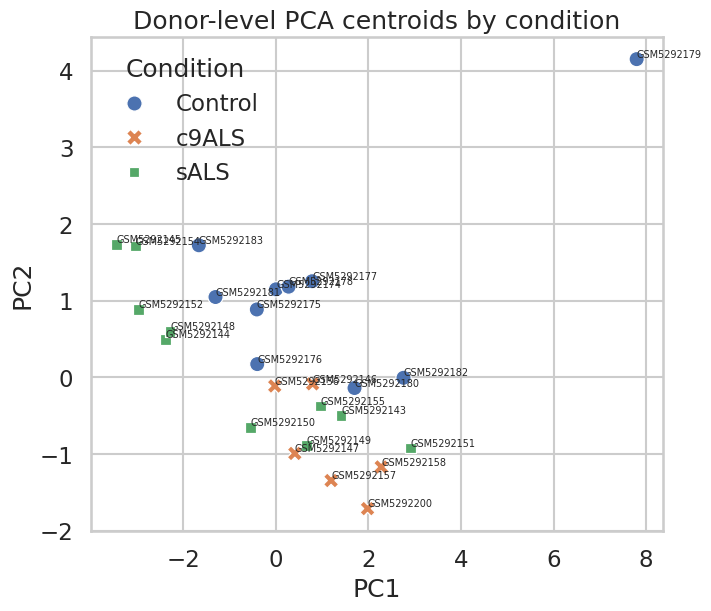

In [8]:
# Donor-level PCA centroid plot

donor_pca = (
    pca_df
    .groupby(["sample", "condition"], observed=True)[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

sns.scatterplot(
    data=donor_pca,
    x="PC1",
    y="PC2",
    hue="condition",
    style="condition",
    s=120,
    ax=ax,
)

for _, row in donor_pca.iterrows():
    ax.text(
        row["PC1"],
        row["PC2"],
        row["sample"],
        fontsize=7,
        ha="left",
        va="bottom",
    )

ax.set_title("Donor-level PCA centroids by condition")
ax.legend(title="Condition", frameon=False)

save_fig(fig, "08_batch_pre_harmony_pca_donor_centroids_condition_26donors.png")
plt.show()

## Pre-Harmony diagnostics


Saved figure: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/08_batch_assessment_26donors/figures/08_batch_pre_harmony_umap_leiden_sample_condition.png


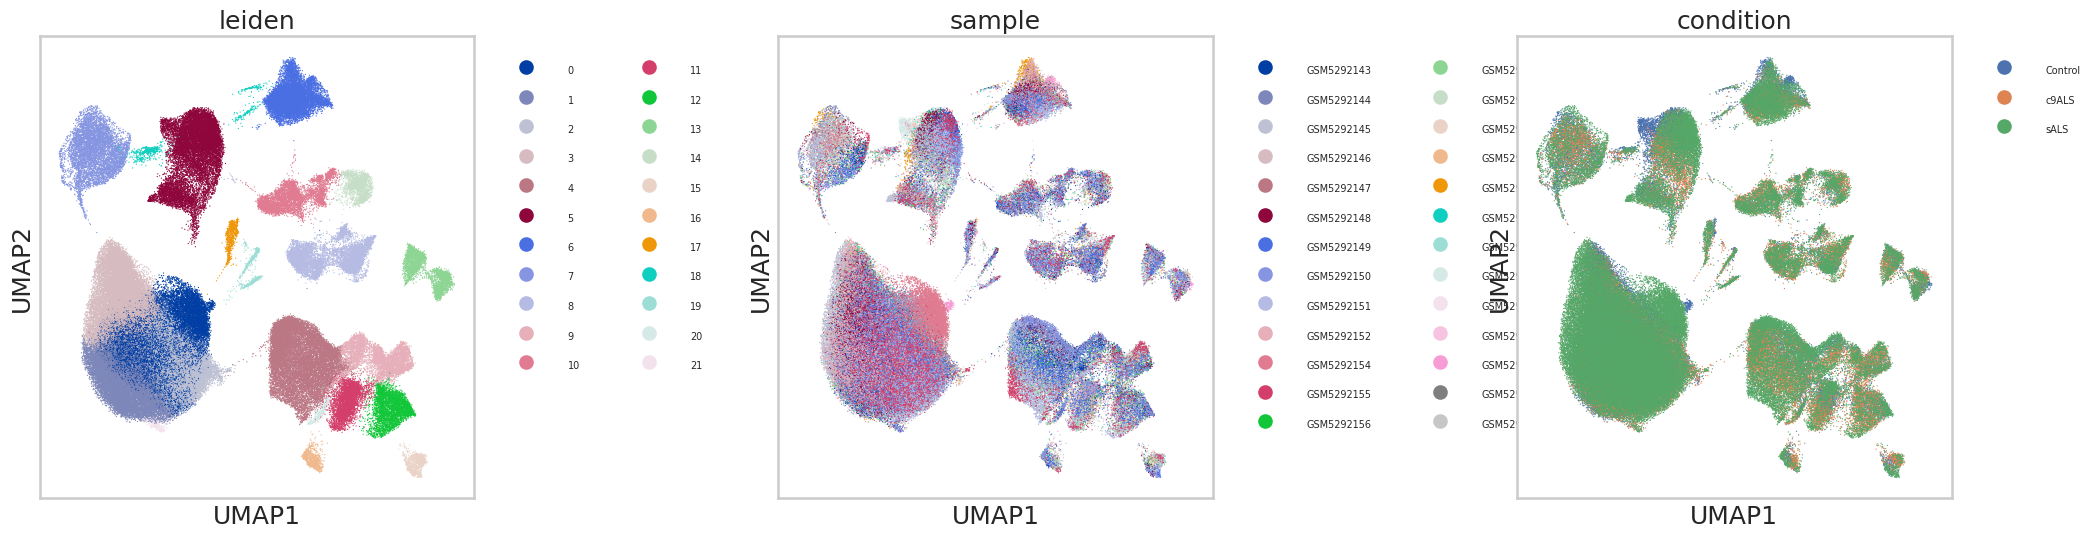

In [8]:
fig = sc.pl.umap(
    adata_merged,
    color=['leiden', 'sample', 'condition'],
    wspace=0.7,
    size=3,
    show=False,
    return_fig=True,
)

fig.set_size_inches(24, 6)

for ax in fig.axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.set_bbox_to_anchor((1.02, 1))
        legend._loc = 2  # upper left
        legend.set_frame_on(False)
        for text in legend.get_texts():
            text.set_fontsize(7)
        if legend.get_title() is not None:
            legend.get_title().set_fontsize(8)

fig.subplots_adjust(right=0.86, wspace=0.75)

save_fig(fig, '08_batch_pre_harmony_umap_leiden_sample_condition.png')
plt.show()

Saved figure: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/08_batch_assessment_26donors/figures/08_batch_pre_harmony_umap_leiden_sample_condition.png


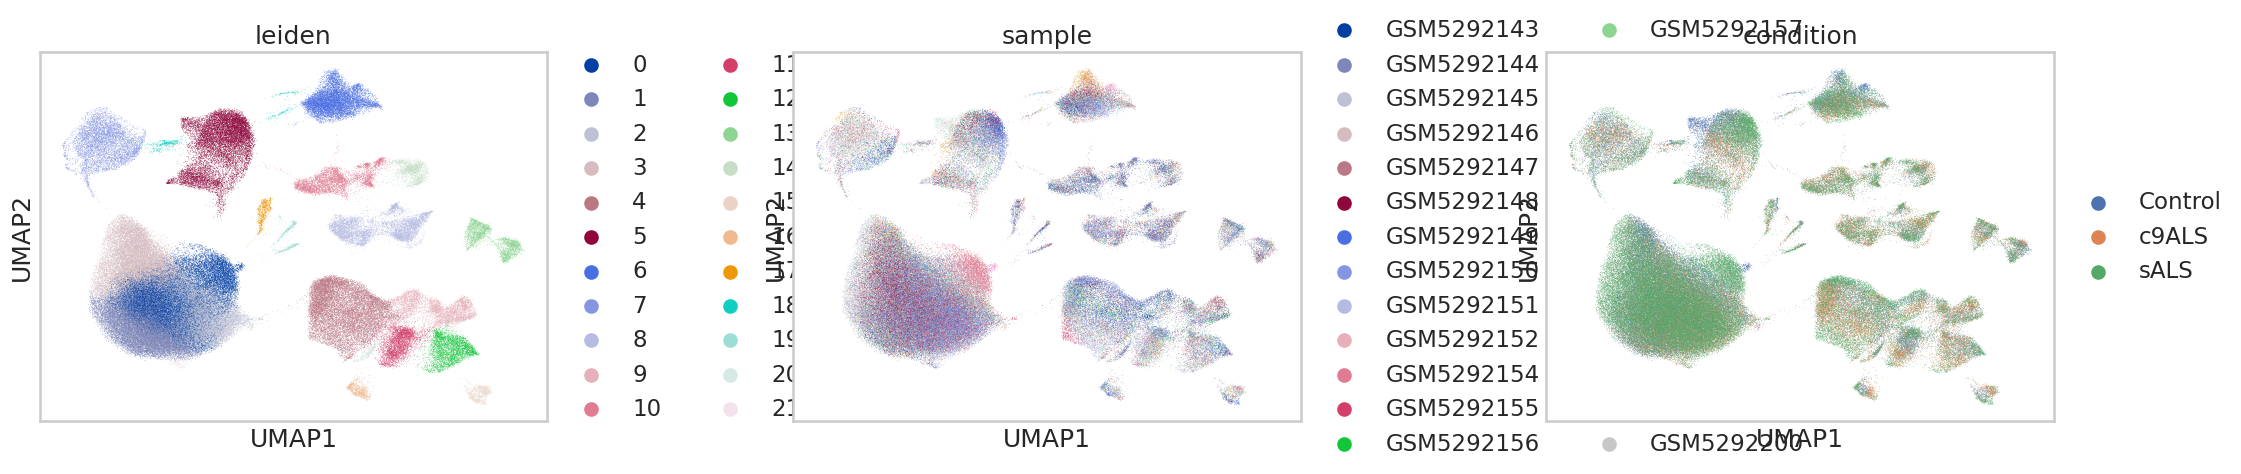

Saved figure: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/08_batch_assessment_26donors/figures/08_batch_pre_harmony_pca_leiden_sample_condition.png


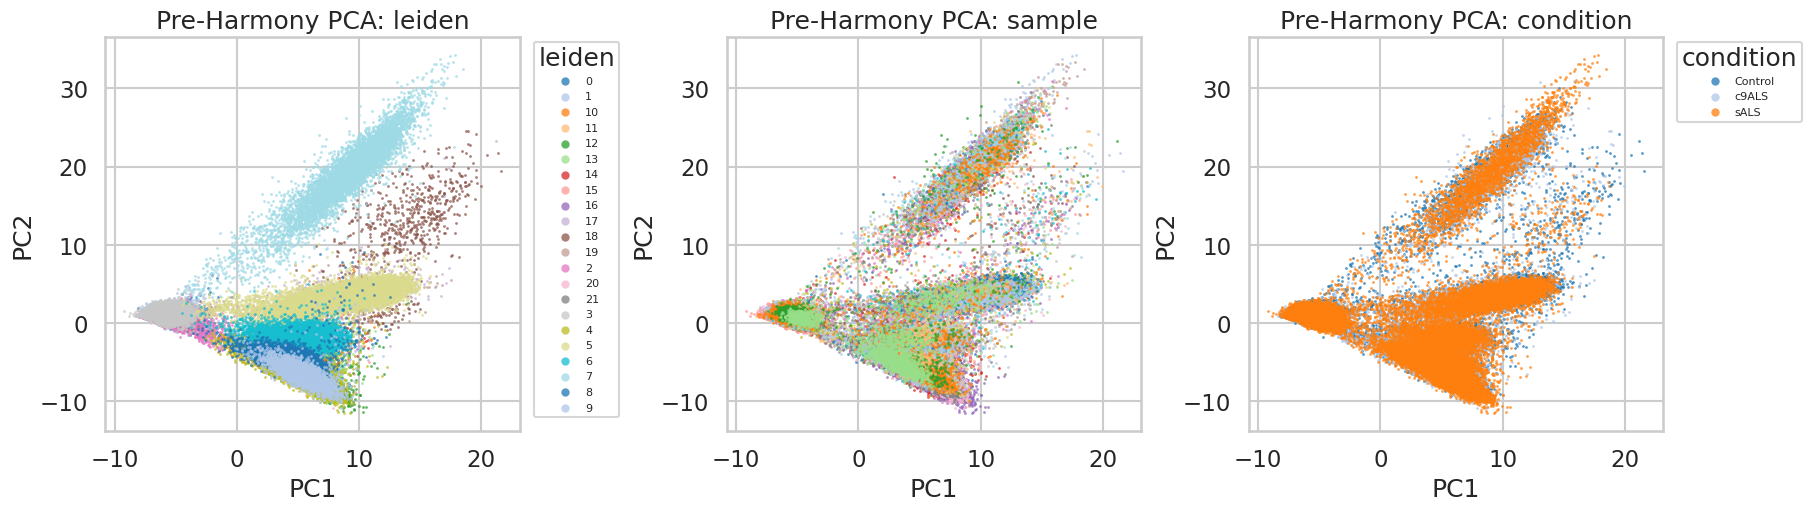

/tmp/slurm_48294838/ipykernel_833167/2901131219.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_sample = pc.groupby('sample')[[f'{pc_prefix}1', f'{pc_prefix}2']].mean().sort_index()
/tmp/slurm_48294838/ipykernel_833167/2901131219.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_condition = pc.groupby('condition')[[f'{pc_prefix}1', f'{pc_prefix}2']].mean().sort_index()


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292149,GSM5292150,GSM5292151,GSM5292152,...,GSM5292175,GSM5292176,GSM5292177,GSM5292178,GSM5292179,GSM5292180,GSM5292181,GSM5292182,GSM5292183,GSM5292200
leiden,,,,,,,,,,,,,,,,,,,,,
0,608,5196,519,1169,1171,2962,640,743,459,428,...,1021,449,456,464,72,530,382,230,389,386
1,1785,960,1491,1802,1030,1296,1081,1647,803,1001,...,781,1067,338,1465,3,1444,752,0,275,17
2,768,819,59,560,1868,886,3166,2318,1248,143,...,863,1178,324,492,22,376,849,5,13,167
3,392,1859,2232,413,535,1773,716,1258,128,1195,...,1115,880,365,665,4,235,1597,6,218,0
4,1350,774,23,752,1342,294,1299,954,1729,2,...,188,122,92,314,1,955,341,28,17,678
5,994,649,259,542,386,616,1184,735,1128,218,...,814,247,376,556,456,760,205,97,66,188
6,468,556,254,403,498,547,632,396,504,382,...,386,761,200,307,92,286,324,222,71,262
7,330,240,162,543,435,119,321,310,547,28,...,235,196,197,425,56,356,373,48,86,41
8,394,216,36,553,829,165,761,510,399,20,...,120,236,87,149,2,336,157,11,23,53


,PC1,PC2
sample,,
GSM5292143,1.406896,-0.502640
GSM5292144,-2.384233,0.490757
GSM5292145,-3.436774,1.732293
GSM5292146,0.793632,-0.086422
GSM5292147,0.409176,-0.993963
GSM5292148,-2.285315,0.594496
GSM5292149,0.661357,-0.892720
GSM5292150,-0.549646,-0.657170
GSM5292151,2.906883,-0.924353


,PC1,PC2
condition,,
Control,0.219962,0.807840
c9ALS,0.986708,-0.818316
sALS,-0.628783,0.012742


,obsm_key,batch_col,raw_batch_asw,batch_mixing_asw_1_minus_abs_asw,n_neighbors,ilisi_mean,ilisi_median,ilisi_min,ilisi_max
0,X_pca,sample,-0.10649,0.89351,30,6.374004,6.338028,1.0,17.307692


In [7]:
plot_embedding_2d(
    adata_merged,
    obsm_key='X_pca',
    color_cols=['leiden', 'sample', 'condition'],
    labels=['PC1', 'PC2'],
    title_prefix='Pre-Harmony PCA',
    filename='08_batch_pre_harmony_pca_leiden_sample_condition.png',
)

pre_cluster_by_sample, pre_pc_by_sample, pre_pc_by_condition = save_batch_tables(
    adata_merged,
    cluster_col='leiden',
    obsm_key='X_pca',
    prefix='08_batch_pre_harmony',
    pc_prefix='PC',
)

pre_metrics = pd.DataFrame([batch_metrics(adata_merged, 'X_pca', batch_col='sample')])
pre_metrics.to_csv(TABLES_DIR / '08_batch_pre_harmony_batch_metrics.csv', index=False)
display(pre_metrics)


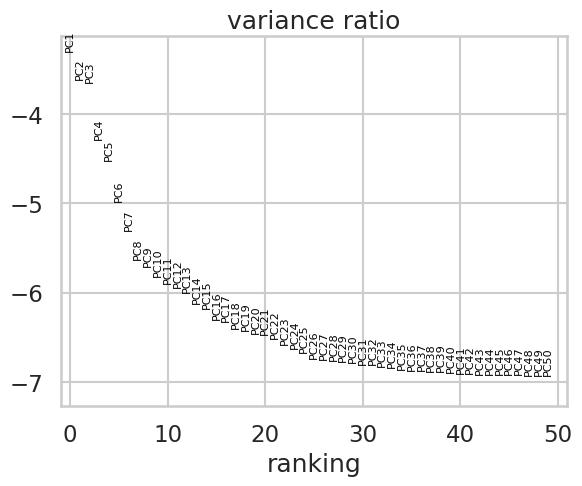

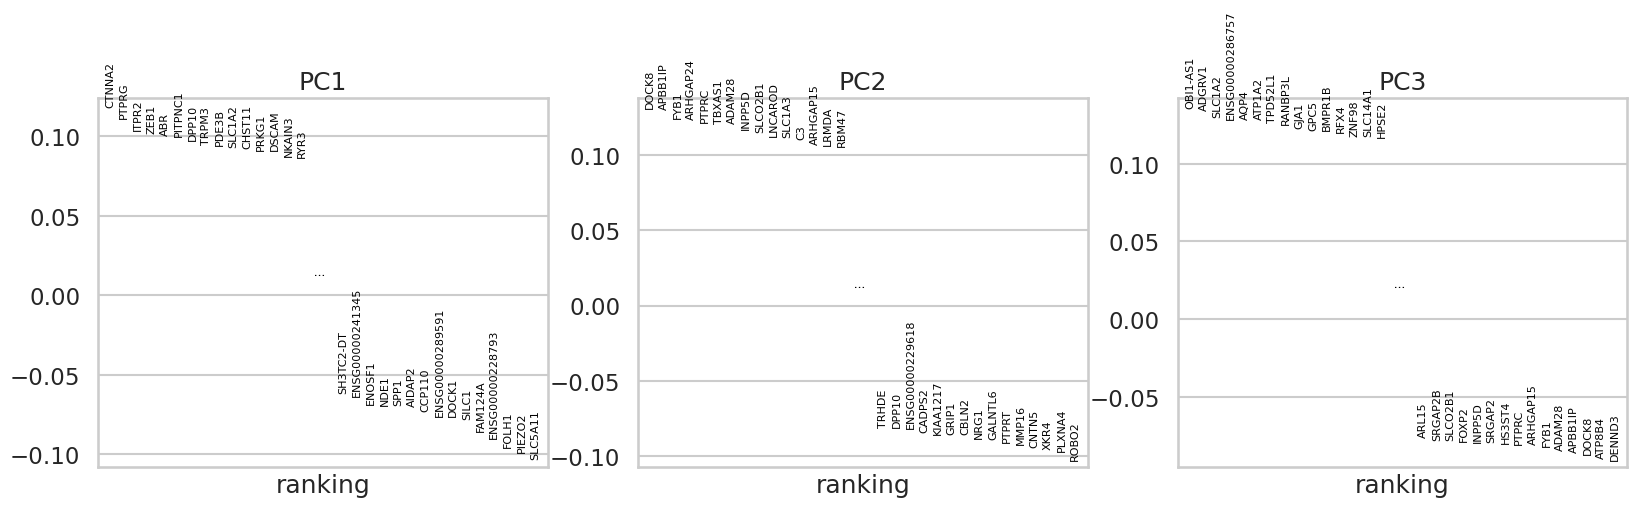

Mean PC1 by sample:


/tmp/slurm_48294838/ipykernel_833167/264275989.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(pca_df.groupby('sample')['PC1'].mean().sort_values())


sample
GSM5292145   -3.436774
GSM5292154   -3.038298
GSM5292152   -2.966554
GSM5292144   -2.384233
GSM5292148   -2.285315
GSM5292183   -1.664279
GSM5292181   -1.304456
GSM5292150   -0.549646
GSM5292175   -0.411972
GSM5292176   -0.402923
GSM5292156   -0.024318
GSM5292174    0.002589
GSM5292178    0.274192
GSM5292147    0.409176
GSM5292149    0.661357
GSM5292177    0.781481
GSM5292146    0.793632
GSM5292155    0.963117
GSM5292157    1.192584
GSM5292143    1.406896
GSM5292180    1.698432
GSM5292200    1.979763
GSM5292158    2.275106
GSM5292182    2.756552
GSM5292151    2.906883
GSM5292179    7.792819
Name: PC1, dtype: float32

Mean PC1 by condition:


/tmp/slurm_48294838/ipykernel_833167/264275989.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(pca_df.groupby('condition')['PC1'].mean().sort_values())


condition
sALS      -0.628783
Control    0.219962
c9ALS      0.986708
Name: PC1, dtype: float32

In [9]:
sc.pl.pca_variance_ratio(adata_merged, log=True, n_pcs=50)
sc.pl.pca_loadings(adata_merged, components=[1, 2, 3], include_lowest=True)

pca_df = pd.DataFrame(adata_merged.obsm['X_pca'][:, :10], index=adata_merged.obs_names, columns=[f'PC{i}' for i in range(1, 11)])
pca_df = pca_df.join(adata_merged.obs[['sample', 'condition']])
print('Mean PC1 by sample:')
display(pca_df.groupby('sample')['PC1'].mean().sort_values())
print('Mean PC1 by condition:')
display(pca_df.groupby('condition')['PC1'].mean().sort_values())


## Harmony integration


2026-06-08 01:30:55,144 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-06-08 01:30:55,145 - harmonypy - INFO -   Parameters:
2026-06-08 01:30:55,145 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-08 01:30:55,146 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-08 01:30:55,146 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-08 01:30:55,146 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-08 01:30:55,146 - harmonypy - INFO -     nclust: 100
2026-06-08 01:30:55,147 - harmonypy - INFO -     block_size: 0.05
2026-06-08 01:30:55,147 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
2026-06-08 01:30:55,148 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2.]
2026-06-08 01:30:55,148 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-08 01:30:55,148 - harmonypy - INFO -     verbose: True
2026-06-08 01:30:55,149 - harmonypy

Saved figure: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/08_batch_assessment_26donors/figures/08_batch_post_harmony_umap_leiden_sample_condition.png


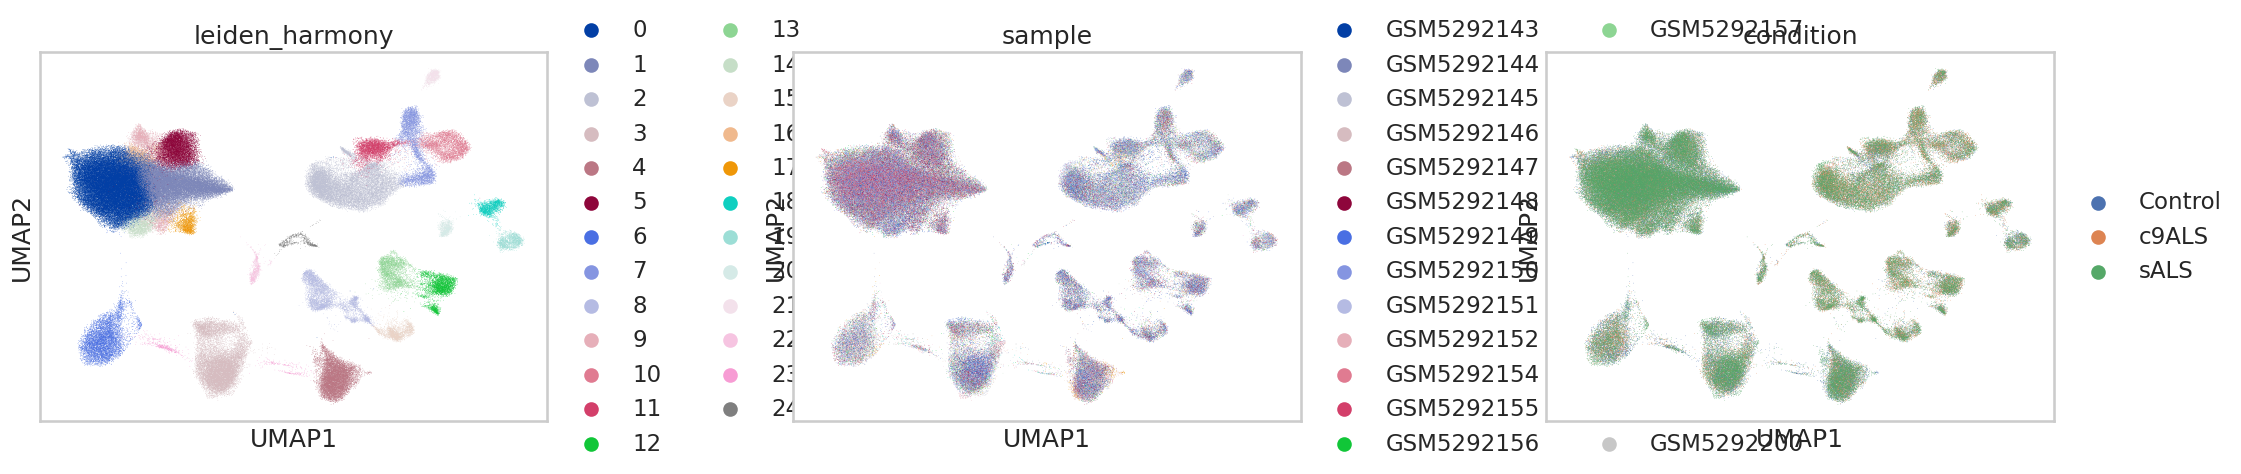

Saved Harmony-integrated object: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/data/processed/merged/adata_hm_after_harmony_26donors.h5ad
AnnData object with n_obs × n_vars = 167326 × 2000
    obs: 'sample', 'condition', 'dataset', 'tissue', 'source_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outliers', 'mt_outliers', 'high_quality_cells', 'soupx_clusters', 'doublet_score_scrublet', 'predicted_doublet_scrublet', 'concat_sample_id', 'leiden', 'leiden_harmony'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'highly_variable', 'mean', 'std'
    uns: 'leiden', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'leiden_colors', 'sample_colors', 'condition_colors', 'leiden_harmony', 'leiden_harmony_c

In [10]:
adata_hm = adata_merged.copy()
x = adata_hm.obsm['X_pca'].astype('float64')
ho = hm.run_harmony(x, adata_hm.obs, vars_use='sample')
z = ho.Z_corr
if z.shape != x.shape:
    z = z.T

adata_hm.obsm[HARMONY_KEY] = z
sc.pp.neighbors(adata_hm, use_rep=HARMONY_KEY)
sc.tl.umap(adata_hm, random_state=0)
sc.tl.leiden(adata_hm, resolution=HARMONY_RESOLUTION, key_added=HARMONY_CLUSTER_KEY)

fig = sc.pl.umap(adata_hm, color=[HARMONY_CLUSTER_KEY, 'sample', 'condition'], wspace=0.35, show=False, return_fig=True)
save_fig(fig, '08_batch_post_harmony_umap_leiden_sample_condition.png')
plt.show()

adata_hm.write_h5ad(HARMONY_PATH)
print(f'Saved Harmony-integrated object: {HARMONY_PATH}')
print(adata_hm)
print('Has X_pca_harmony:', HARMONY_KEY in adata_hm.obsm)
print('Has leiden_harmony:', HARMONY_CLUSTER_KEY in adata_hm.obs)


## Post-Harmony diagnostics


Saved figure: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/08_batch_assessment_26donors/figures/08_batch_post_harmony_pca_leiden_sample_condition.png


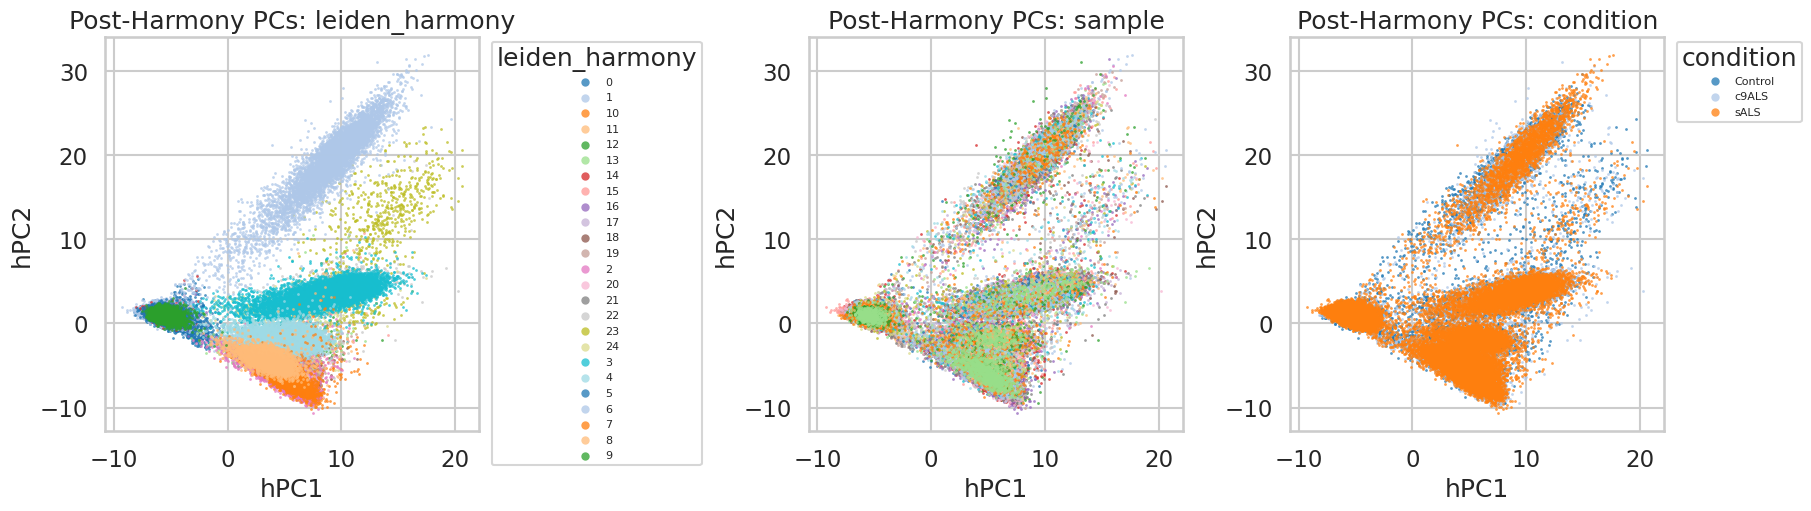

/tmp/slurm_48294838/ipykernel_833167/2901131219.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_sample = pc.groupby('sample')[[f'{pc_prefix}1', f'{pc_prefix}2']].mean().sort_index()
/tmp/slurm_48294838/ipykernel_833167/2901131219.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_condition = pc.groupby('condition')[[f'{pc_prefix}1', f'{pc_prefix}2']].mean().sort_index()


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292149,GSM5292150,GSM5292151,GSM5292152,...,GSM5292175,GSM5292176,GSM5292177,GSM5292178,GSM5292179,GSM5292180,GSM5292181,GSM5292182,GSM5292183,GSM5292200
leiden_harmony,,,,,,,,,,,,,,,,,,,,,
0,1848,4526,1990,1969,2557,3203,3025,3070,1470,1269,...,1753,1869,754,1514,68,1282,1632,164,416,402
1,801,2838,1560,931,1199,2217,1505,1777,566,1016,...,1176,1074,429,839,18,604,1248,37,310,82
2,1273,780,26,801,1321,295,1321,989,1681,49,...,209,212,134,339,1,970,350,57,18,647
3,994,652,258,541,386,609,1182,733,1127,218,...,814,246,379,551,455,761,202,97,66,188
4,468,553,254,403,497,546,632,393,503,378,...,384,759,198,308,92,286,322,220,68,262
5,432,731,355,444,435,677,375,433,366,235,...,464,348,112,295,0,281,280,16,87,33
6,330,240,161,544,436,117,318,310,547,28,...,236,197,198,423,56,354,373,51,85,41
7,337,189,23,365,542,130,398,308,388,9,...,112,76,73,165,3,288,99,4,23,114
8,550,289,24,209,444,180,427,325,407,10,...,58,84,21,95,2,272,132,10,6,98


,hPC1,hPC2
sample,,
GSM5292143,1.312840,-0.558899
GSM5292144,-2.125299,0.335795
GSM5292145,-3.231354,1.262505
GSM5292146,0.807013,-0.182654
GSM5292147,0.591255,-0.963847
GSM5292148,-2.255639,0.481311
GSM5292149,0.642138,-0.632840
GSM5292150,-0.379574,-0.299783
GSM5292151,2.636150,-0.480617


,hPC1,hPC2
condition,,
Control,0.107382,0.704482
c9ALS,1.118891,-0.745768
sALS,-0.642602,0.076739


,obsm_key,batch_col,raw_batch_asw,batch_mixing_asw_1_minus_abs_asw,n_neighbors,ilisi_mean,ilisi_median,ilisi_min,ilisi_max
0,X_pca_harmony,sample,-0.141127,0.858873,30,9.957766,10.0,1.068884,20.454545


In [11]:
plot_embedding_2d(
    adata_hm,
    obsm_key=HARMONY_KEY,
    color_cols=[HARMONY_CLUSTER_KEY, 'sample', 'condition'],
    labels=['hPC1', 'hPC2'],
    title_prefix='Post-Harmony PCs',
    filename='08_batch_post_harmony_pca_leiden_sample_condition.png',
)

post_cluster_by_sample, post_pc_by_sample, post_pc_by_condition = save_batch_tables(
    adata_hm,
    cluster_col=HARMONY_CLUSTER_KEY,
    obsm_key=HARMONY_KEY,
    prefix='08_batch_post_harmony',
    pc_prefix='hPC',
)

post_metrics = pd.DataFrame([batch_metrics(adata_hm, HARMONY_KEY, batch_col='sample')])
post_metrics.to_csv(TABLES_DIR / '08_batch_post_harmony_batch_metrics.csv', index=False)
display(post_metrics)
